# Homework 3: Classification

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load SPAMBASE dataset
# Column names from spambase.names
col_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_semicolon', 'char_freq_parenthesis', 'char_freq_bracket',
    'char_freq_exclamation', 'char_freq_dollar', 'char_freq_pound',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total', 'spam'
]

df = pd.read_csv('spambase.data', header=None, names=col_names)
print(f'Dataset shape: {df.shape}')
print(f'Class distribution:\n{df["spam"].value_counts()}')
df.head()

Dataset shape: (4601, 58)
Class distribution:
spam
0    2788
1    1813
Name: count, dtype: int64


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_parenthesis,char_freq_bracket,char_freq_exclamation,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [7]:
# Prepare features and labels
X = df.drop(columns=['spam']).values
y = df['spam'].values
feature_names = df.drop(columns=['spam']).columns.tolist()

# 75/25 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Testing set:  {X_test.shape}')

Training set: (3450, 57)
Testing set:  (1151, 57)


---
# Problem 1: Logistic Regression

## Part 1: Train and Evaluate

In [9]:
# Train logistic regression with sklearn
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# 1a. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix (rows=actual, cols=predicted):')
print(f'           Predicted HAM  Predicted SPAM')
print(f'Actual HAM       {cm[0,0]:5d}         {cm[0,1]:5d}')
print(f'Actual SPAM      {cm[1,0]:5d}         {cm[1,1]:5d}')

# 1b. Accuracy and Error
acc  = accuracy_score(y_test, y_pred)
err  = 1 - acc

# 1c. Precision, Recall, F1
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f'\nAccuracy:  {acc:.4f}')
print(f'Error:     {err:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 Score:  {f1:.4f}')

Confusion Matrix (rows=actual, cols=predicted):
           Predicted HAM  Predicted SPAM
Actual HAM         650            26
Actual SPAM         58           417

Accuracy:  0.9270
Error:     0.0730
Precision: 0.9413
Recall:    0.8779
F1 Score:  0.9085


## Part 2: Feature Coefficients

In [17]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

print('All feature coefficients (sorted by value):')
print(coef_df.to_string(index=False))

print('\n--- Top 5 Positively Correlated with SPAM ---')
print(coef_df.head(5).to_string(index=False))

print('\n--- Top 5 Negatively Correlated with SPAM ---')
print(coef_df.tail(5).to_string(index=False))

All feature coefficients (sorted by value):
                   Feature  Coefficient
          char_freq_dollar     3.247768
             word_freq_000     2.381522
          word_freq_remove     2.233783
       word_freq_addresses     1.154980
      word_freq_technology     1.092929
            word_freq_free     1.034438
          word_freq_credit     0.947807
           char_freq_pound     0.938559
        word_freq_business     0.817725
              word_freq_3d     0.670976
           word_freq_order     0.657152
             word_freq_our     0.629067
            word_freq_over     0.621816
        word_freq_internet     0.564632
           word_freq_money     0.395667
             word_freq_650     0.332717
            word_freq_your     0.255865
            word_freq_font     0.247751
     char_freq_exclamation     0.225114
             word_freq_all     0.158089
          word_freq_report     0.099264
             word_freq_you     0.095420
           word_freq_email     0.084

## Part 3: Varying Decision Threshold

In [19]:
y_prob = lr.predict_proba(X_test)[:, 1]

thresholds = [0.25, 0.5, 0.75, 0.9]
print(f'{'Threshold':>10}  {'Accuracy':>9}  {'Precision':>10}  {'Recall':>7}')
print('-' * 45)
for T in thresholds:
    y_pred_T = (y_prob >= T).astype(int)
    a = accuracy_score(y_test, y_pred_T)
    p = precision_score(y_test, y_pred_T, zero_division=0)
    r = recall_score(y_test, y_pred_T, zero_division=0)
    print(f'{T:>10.2f}  {a:>9.4f}  {p:>10.4f}  {r:>7.4f}')

 Threshold   Accuracy   Precision   Recall
---------------------------------------------
      0.25     0.9079      0.8398   0.9600
      0.50     0.9270      0.9413   0.8779
      0.75     0.8897      0.9603   0.7642
      0.90     0.8228      0.9689   0.5895


---
# Problem 2: Gradient Descent for Logistic Regression

In [21]:
# Standardize features for GD
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def cross_entropy_loss(X, y, theta):
    """Compute binary cross-entropy loss."""
    N = len(y)
    X_b = np.column_stack([np.ones(N), X])
    p = sigmoid(X_b @ theta)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def gd_logistic(X, y, alpha, num_iterations):
    """Gradient descent for logistic regression."""
    N, d = X.shape
    theta = np.zeros(d + 1)
    X_b = np.column_stack([np.ones(N), X])
    loss_history = []

    for _ in range(num_iterations):
        p = sigmoid(X_b @ theta)
        gradient = (1 / N) * X_b.T @ (p - y)
        theta -= alpha * gradient
        loss_history.append(cross_entropy_loss(X, y, theta))

    return theta, loss_history

def predict_gd(X, theta, threshold=0.5):
    N = len(X)
    X_b = np.column_stack([np.ones(N), X])
    return (sigmoid(X_b @ theta) >= threshold).astype(int)

print('Functions defined.')

Functions defined.


In [23]:
learning_rates = [0.001, 0.01, 0.1]
checkpoints = [10, 50, 100]

print('Cross-Entropy Loss at each checkpoint:')
print(f'{'LR':>7}  {'iter=10':>10}  {'iter=50':>10}  {'iter=100':>10}')
print('-' * 45)

gd_models = {}
for alpha in learning_rates:
    theta, losses = gd_logistic(X_train_s, y_train, alpha, 100)
    gd_models[alpha] = (theta, losses)
    row = f'{alpha:>7.3f}'
    for cp in checkpoints:
        row += f'  {losses[cp-1]:>10.6f}'
    print(row)

Cross-Entropy Loss at each checkpoint:
     LR     iter=10     iter=50    iter=100
---------------------------------------------
  0.001    0.688583    0.671212    0.651333
  0.010    0.651167    0.541620    0.468734
  0.100    0.465377    0.324124    0.289078


In [25]:
print('Metrics at 100 iterations (on train/test) vs sklearn:')
print(f'{'Model':>20}  {'Acc':>7}  {'Prec':>7}  {'Rec':>7}  {'F1':>7}')
print('-' * 60)

for alpha in learning_rates:
    theta, _ = gd_models[alpha]
    for split, X_s, y_s in [('train', X_train_s, y_train), ('test', X_test_s, y_test)]:
        yp = predict_gd(X_s, theta)
        a  = accuracy_score(y_s, yp)
        p  = precision_score(y_s, yp, zero_division=0)
        r  = recall_score(y_s, yp, zero_division=0)
        f  = f1_score(y_s, yp, zero_division=0)
        print(f'GD α={alpha:.3f} ({split:>5}):  {a:>7.4f}  {p:>7.4f}  {r:>7.4f}  {f:>7.4f}')

# Sklearn baseline
for split, X_s, y_s in [('train', X_train, y_train), ('test', X_test, y_test)]:
    yp = lr.predict(X_s)
    a  = accuracy_score(y_s, yp)
    p  = precision_score(y_s, yp, zero_division=0)
    r  = recall_score(y_s, yp, zero_division=0)
    f  = f1_score(y_s, yp, zero_division=0)
    print(f'sklearn LR  ({split:>5}):  {a:>7.4f}  {p:>7.4f}  {r:>7.4f}  {f:>7.4f}')

Metrics at 100 iterations (on train/test) vs sklearn:
               Model      Acc     Prec      Rec       F1
------------------------------------------------------------
GD α=0.001 (train):   0.8959   0.8607   0.8729   0.8668
GD α=0.001 ( test):   0.8992   0.8811   0.8737   0.8774
GD α=0.010 (train):   0.8977   0.8734   0.8610   0.8671
GD α=0.010 ( test):   0.9036   0.9009   0.8611   0.8805
GD α=0.100 (train):   0.9078   0.9113   0.8445   0.8766
GD α=0.100 ( test):   0.9062   0.9238   0.8421   0.8811
sklearn LR  (train):   0.9290   0.9273   0.8864   0.9064
sklearn LR  ( test):   0.9270   0.9413   0.8779   0.9085


---
# Problem 3: Comparing Classifiers

## Part 1: Cross-Validation for kNN k-selection

In [29]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5,
                             scoring='accuracy')
    cv_results.append({
        'k': k,
        'CV Accuracy': scores.mean(),
        'CV Error': 1 - scores.mean(),
        'CV Precision': cross_val_score(knn, X_train, y_train, cv=5,
                                        scoring='precision').mean(),
        'CV Recall': cross_val_score(knn, X_train, y_train, cv=5,
                                     scoring='recall').mean()
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))

best_k = int(cv_df.loc[cv_df['CV Error'].idxmin(), 'k'])
print(f'\nBest k (min CV error): {best_k}')

 k  CV Accuracy  CV Error  CV Precision  CV Recall
 1     0.805217  0.194783      0.752003   0.742931
 3     0.799710  0.200290      0.748601   0.728736
 5     0.792464  0.207536      0.741968   0.713782
 7     0.786957  0.213043      0.733097   0.709302
 9     0.786667  0.213333      0.731749   0.710783
11     0.783188  0.216812      0.728307   0.704047
15     0.773623  0.226377      0.714097   0.694348
21     0.764058  0.235942      0.705214   0.674160
31     0.754493  0.245507      0.693554   0.658447

Best k (min CV error): 1


## Part 2: Compare All 3 Classifiers

In [13]:
classifiers = {
    'Logistic Regression': lr,
    'LDA': LinearDiscriminantAnalysis(),
    'kNN (best k)': KNeighborsClassifier(n_neighbors=best_k)
}

# Train LDA and kNN (LR already trained)
classifiers['LDA'].fit(X_train, y_train)
classifiers['kNN (best k)'].fit(X_train, y_train)

rows = []
for name, clf in classifiers.items():
    for split, X_s, y_s in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        yp = clf.predict(X_s)
        rows.append({
            'Classifier': name,
            'Split': split,
            'Accuracy': accuracy_score(y_s, yp),
            'Error': 1 - accuracy_score(y_s, yp),
            'Precision': precision_score(y_s, yp, zero_division=0),
            'Recall': recall_score(y_s, yp, zero_division=0)
        })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

         Classifier Split  Accuracy    Error  Precision   Recall
Logistic Regression Train  0.928986 0.071014   0.927287 0.886398
Logistic Regression  Test  0.927020 0.072980   0.941309 0.877895
                LDA Train  0.886667 0.113333   0.915716 0.779522
                LDA  Test  0.885317 0.114683   0.929825 0.781053
       kNN (best k) Train  0.999420 0.000580   0.999253 0.999253
       kNN (best k)  Test  0.800174 0.199826   0.757895 0.757895


## Part 3: ROC Curve using Package

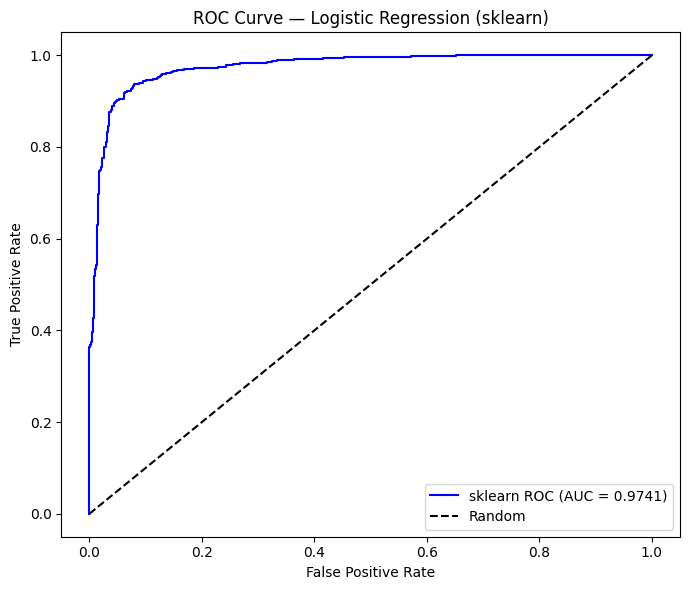

AUC (sklearn): 0.9741


In [14]:
y_prob_test = lr.predict_proba(X_test)[:, 1]
fpr_pkg, tpr_pkg, _ = roc_curve(y_test, y_prob_test)
roc_auc_pkg = auc(fpr_pkg, tpr_pkg)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_pkg, tpr_pkg, label=f'sklearn ROC (AUC = {roc_auc_pkg:.4f})', color='blue')
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression (sklearn)')
ax.legend()
plt.tight_layout()
plt.savefig('p3_roc_pkg.png', dpi=120)
plt.show()
print(f'AUC (sklearn): {roc_auc_pkg:.4f}')

## Part 4: ROC Curve without Package

T=0.0: FPR=1.0000, TPR=1.0000
T=0.1: FPR=0.3107, TPR=0.9832
T=0.2: FPR=0.1672, TPR=0.9684
T=0.3: FPR=0.0947, TPR=0.9411
T=0.4: FPR=0.0607, TPR=0.9116
T=0.5: FPR=0.0385, TPR=0.8779
T=0.6: FPR=0.0311, TPR=0.8274
T=0.7: FPR=0.0266, TPR=0.7916
T=0.8: FPR=0.0178, TPR=0.7158
T=0.9: FPR=0.0133, TPR=0.5895
T=1.0: FPR=0.0000, TPR=0.0000


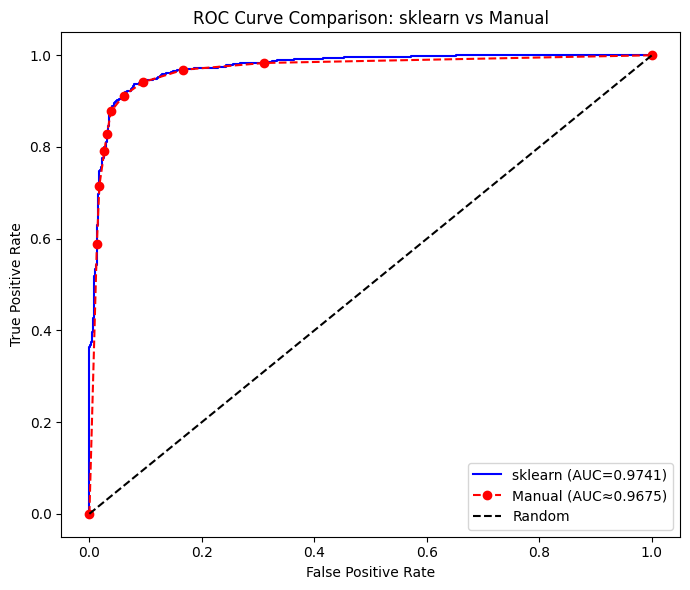

Manual AUC (trapezoidal): 0.9675


In [15]:
thresholds_roc = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
manual_fpr = []
manual_tpr = []

for T in thresholds_roc:
    y_pred_T = (y_prob_test >= T).astype(int)
    TP = np.sum((y_pred_T == 1) & (y_test == 1))
    TN = np.sum((y_pred_T == 0) & (y_test == 0))
    FP = np.sum((y_pred_T == 1) & (y_test == 0))
    FN = np.sum((y_pred_T == 0) & (y_test == 1))
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    manual_fpr.append(fpr)
    manual_tpr.append(tpr)
    print(f'T={T:.1f}: FPR={fpr:.4f}, TPR={tpr:.4f}')

# Approximate AUC via trapezoidal rule
sorted_pairs = sorted(zip(manual_fpr, manual_tpr))
s_fpr, s_tpr = zip(*sorted_pairs)
manual_auc = np.trapz(s_tpr, s_fpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_pkg, tpr_pkg, label=f'sklearn (AUC={roc_auc_pkg:.4f})', color='blue')
ax.plot(s_fpr, s_tpr, 'ro--', label=f'Manual (AUC≈{manual_auc:.4f})', markersize=6)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison: sklearn vs Manual')
ax.legend()
plt.tight_layout()
plt.savefig('p3_roc_comparison.png', dpi=120)
plt.show()
print(f'Manual AUC (trapezoidal): {manual_auc:.4f}')

---
# Problem 4: k-Fold Cross-Validation

## Part 1: Implement k-Fold CV

In [16]:
def my_kfold_cv(clf_class, clf_kwargs, X, y, k):
    """
    Custom k-fold cross-validation.
    Steps:
      1. Divide data into k equal partitions.
      2. For each fold i, train on k-1 partitions, test on fold i.
      3. Record validation error per fold.
      4. Return average validation error.
    """
    N = len(y)
    indices = np.arange(N)
    # Shuffle for random partitioning
    rng = np.random.default_rng(42)
    rng.shuffle(indices)

    fold_size = N // k
    val_errors = []

    for i in range(k):
        # Step 1: Define partition i as validation set
        val_idx   = indices[i * fold_size : (i + 1) * fold_size]
        train_idx = np.concatenate([indices[:i * fold_size],
                                    indices[(i + 1) * fold_size:]])

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # Step 2: Train on k-1 partitions
        clf = clf_class(**clf_kwargs)
        clf.fit(X_tr, y_tr)

        # Step 3: Record validation error
        y_val_pred = clf.predict(X_val)
        val_err = 1 - accuracy_score(y_val, y_val_pred)
        val_errors.append(val_err)

    # Step 4: Average validation error
    avg_error = np.mean(val_errors)
    return val_errors, avg_error

print('my_kfold_cv defined.')

my_kfold_cv defined.


## Part 2: Run CV for Logistic Regression and LDA

In [17]:
# Use entire dataset for CV as per problem statement
X_all = df.drop(columns=['spam']).values
y_all = df['spam'].values

models_cv = {
    'Logistic Regression': (LogisticRegression, {'max_iter': 1000, 'random_state': 42}),
    'LDA':                 (LinearDiscriminantAnalysis, {})
}

print(f'{'Model':>25}  {'k':>3}  {'Avg Val Error':>14}  {'Per-Fold Errors'}')
print('-' * 85)

cv_summary = []
for model_name, (clf_class, clf_kwargs) in models_cv.items():
    for k in [5, 10]:
        fold_errors, avg_err = my_kfold_cv(clf_class, clf_kwargs, X_all, y_all, k)
        cv_summary.append({'Model': model_name, 'k': k, 'Avg Val Error': avg_err})
        fold_str = '  '.join([f'{e:.4f}' for e in fold_errors])
        print(f'{model_name:>25}  {k:>3}  {avg_err:>14.6f}  {fold_str}')

                    Model    k   Avg Val Error  Per-Fold Errors
-------------------------------------------------------------------------------------
      Logistic Regression    5        0.075217  0.0707  0.0707  0.0717  0.0848  0.0783
      Logistic Regression   10        0.069783  0.0522  0.0761  0.0391  0.0761  0.0522  0.0870  0.1065  0.0609  0.0652  0.0826
                      LDA    5        0.112826  0.0978  0.1054  0.1152  0.1315  0.1141
                      LDA   10        0.113478  0.0913  0.1152  0.0870  0.1196  0.1000  0.1283  0.1500  0.1152  0.1174  0.1109


## Part 3: Compare Models

In [18]:
cv_sum_df = pd.DataFrame(cv_summary)
print('Summary — Average Validation Error:')
print(cv_sum_df.to_string(index=False))

best = cv_sum_df.loc[cv_sum_df['Avg Val Error'].idxmin()]
print(f'\nBest model: {best["Model"]} with k={best["k"]} (Avg Val Error = {best["Avg Val Error"]:.6f})')

Summary — Average Validation Error:
              Model  k  Avg Val Error
Logistic Regression  5       0.075217
Logistic Regression 10       0.069783
                LDA  5       0.112826
                LDA 10       0.113478

Best model: Logistic Regression with k=10 (Avg Val Error = 0.069783)
